<a href="https://colab.research.google.com/github/xamsnrub/Project-141A/blob/main/BERTVSCHATGPT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# --- Upload CSV, analyze, and plot (Colab) ---
import io, re, textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

# 1) Upload your CSV (choose your *scored* file, e.g. twitter_experiment_scored.csv)
uploaded = files.upload()
csv_name = list(uploaded.keys())[0]
print(f"Using uploaded file: {csv_name}")

# 2) Load and clean
df = pd.read_csv(io.BytesIO(uploaded[csv_name]))

# Ensure expected columns
if "BERT" not in df.columns or "chat" not in df.columns:
    raise ValueError("Expected numeric columns 'BERT' and 'chat' in the CSV.")
# find text column flexibly
text_col = "text" if "text" in df.columns else ("tweets" if "tweets" in df.columns else None)
if text_col is None:
    # fallback to first object column
    for c in df.columns:
        if df[c].dtype == object:
            text_col = c
            break
if text_col is None:
    raise ValueError("Could not find a text column. Make sure the CSV has 'text' or 'tweets'.")

# Coerce scores to numeric, drop rows missing either
df["BERT"] = pd.to_numeric(df["BERT"], errors="coerce")
df["chat"] = pd.to_numeric(df["chat"], errors="coerce")
df = df.dropna(subset=["BERT", "chat"]).copy()
df[text_col] = df[text_col].astype(str)

# 3) Quick features (optional, handy for later)
def count_pattern(s, pattern):
    return len(re.findall(pattern, s))

def uppercase_ratio(s):
    ups = sum(1 for ch in s if ch.isupper())
    letters = sum(1 for ch in s if ch.isalpha())
    return ups / letters if letters > 0 else 0.0

def url_count(s):
    return len(re.findall(r"(https?://\S+)", s))

def word_count(s):
    return len(re.findall(r"\b\w+\b", s))

df["len_chars"] = df[text_col].str.len()
df["len_words"] = df[text_col].apply(word_count)
df["num_hashtags"] = df[text_col].apply(lambda s: count_pattern(s, r"#\w+"))
df["num_mentions"] = df[text_col].apply(lambda s: count_pattern(s, r"@\w+"))
df["num_urls"] = df[text_col].apply(url_count)
df["num_exclaims"] = df[text_col].apply(lambda s: s.count("!"))
df["num_questions"] = df[text_col].apply(lambda s: s.count("?"))
df["upper_ratio"] = df[text_col].apply(uppercase_ratio)

# 4) Derived: gap
df["gap"] = df["chat"] - df["BERT"]

# 5) Tiny summary
print("\n=== Summary ===")
print(f"Rows: {len(df)}")
print(f"BERT mean ± sd: {df['BERT'].mean():.3f} ± {df['BERT'].std():.3f}")
print(f"Chat mean ± sd:  {df['chat'].mean():.3f} ± {df['chat'].std():.3f}")
print(f"Gap  mean ± sd:  {df['gap'].mean():.3f} ± {df['gap'].std():.3f}")
print(f"Correlation (BERT, Chat): {df['BERT'].corr(df['chat']):.3f}")

# 6) Plots (matplotlib; no seaborn; one figure per plot; default colors)
# Histogram of BERT
plt.figure()
plt.hist(df["BERT"].dropna(), bins=20)
plt.title("Histogram of BERT scores")
plt.xlabel("BERT score")
plt.ylabel("Count")
plt.show()

# Histogram of Chat
plt.figure()
plt.hist(df["chat"].dropna(), bins=20)
plt.title("Histogram of Chat scores")
plt.xlabel("Chat score")
plt.ylabel("Count")
plt.show()

# Scatter: BERT vs Chat
plt.figure()
plt.scatter(df["BERT"], df["chat"], alpha=0.7)
plt.title("BERT vs Chat scores")
plt.xlabel("BERT")
plt.ylabel("Chat")
plt.show()

# Histogram of (chat - BERT) gap
plt.figure()
plt.hist(df["gap"].dropna(), bins=20)
plt.title("Histogram of (chat - BERT) gap")
plt.xlabel("Gap (chat - BERT)")
plt.ylabel("Count")
plt.show()

# 7) Top disagreements table (optional print)
top_disagree = df.reindex(df["gap"].abs().sort_values(ascending=False).index).head(10)[
    [text_col,"BERT","chat","gap","len_words","num_hashtags","num_exclaims","upper_ratio"]
].copy()

# Wrap long text for readability in console
def shorten(s, width=120):
    return textwrap.shorten(s, width=width, placeholder="…")

top_disagree[text_col] = top_disagree[text_col].apply(shorten)
print("\n=== Top 10 disagreements by |gap| ===")
print(top_disagree.to_string(index=False))


KeyboardInterrupt: 

Saving twitter_experiment_scored.csv to twitter_experiment_scored (1).csv
Using uploaded file: twitter_experiment_scored (1).csv
Rows after cleaning: 200

=== OLS (HC3 robust SE) summary ===
                            OLS Regression Results                            
Dep. Variable:                    gap   R-squared:                       0.100
Model:                            OLS   Adj. R-squared:                  0.068
Method:                 Least Squares   F-statistic:                     2.227
Date:                Wed, 12 Nov 2025   Prob (F-statistic):             0.0337
Time:                        03:38:40   Log-Likelihood:                -150.51
No. Observations:                 200   AIC:                             317.0
Df Residuals:                     192   BIC:                             343.4
Df Model:                           7                                         
Covariance Type:                  HC3                                         
                   

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 10, but rank is 7
  warnings.warn('covariance of constraints does not have full '


,term,coef,std_err_HC3,t,p_value
0,const,-1.937882e-01,4.679939e-02,-4.140828,0.000035
1,len_words,-3.778804e-01,2.197272e-01,-1.719771,0.085474
2,len_chars,4.510203e-01,2.213856e-01,2.037262,0.041624
3,upper_ratio,3.644991e-04,3.462721e-02,0.010526,0.991601
4,num_hashtags,-5.103140e-03,1.918608e-01,-0.026598,0.978780
5,num_mentions,8.231581e-02,1.008410e-01,0.816293,0.414333
6,num_urls,1.357302e-16,7.804723e-17,1.739078,0.082021
7,num_exclaims,-9.768691e-02,3.866970e-02,-2.526187,0.011531
8,num_questions,-4.507164e-02,3.508709e-02,-1.284565,0.198944
9,has_hashtag,-5.103140e-03,1.918608e-01,-0.026598,0.978780



=== VIF (Variance Inflation Factor) ===


/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss


,feature,VIF
3,num_hashtags,inf
8,has_hashtag,inf
1,len_chars,28.550777
0,len_words,28.177842
2,upper_ratio,1.049819
6,num_exclaims,1.038556
7,num_questions,1.013875
4,num_mentions,1.006796
5,num_urls,NaN
9,has_url,NaN



=== LassoCV coefficients (standardized features) ===
Chosen alpha: 0.001805


,feature,coef
1,len_chars,0.346140
4,num_mentions,0.079391
8,has_hashtag,-0.000000
2,upper_ratio,-0.000000
5,num_urls,0.000000
9,has_url,0.000000
3,num_hashtags,-0.003360
7,num_questions,-0.044661
6,num_exclaims,-0.095674
0,len_words,-0.273934


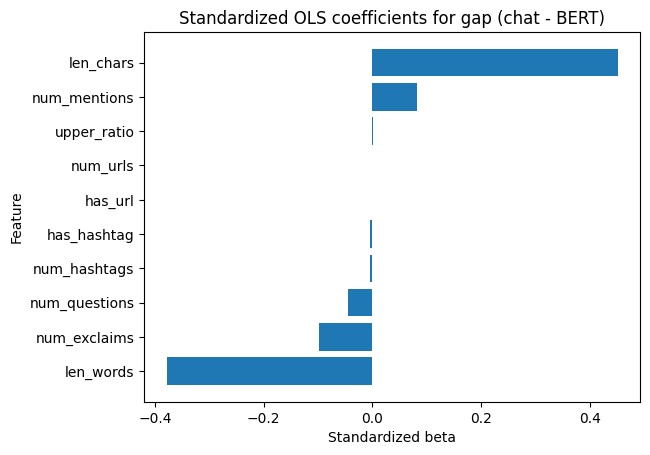


=== Quick reads ===
* Positive beta => larger feature value is associated with Chat > BERT (bigger gap).
* Negative beta => larger feature value is associated with BERT > Chat (smaller/negative gap).
* Check p-values for statistical strength and VIF to watch multicollinearity.


In [ ]:
# === Upload, feature engineering, and model comparison (OLS + Lasso) ===
import io, re, textwrap, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

# 1) Upload your *scored* CSV (must contain BERT, chat, and a text-like column)
uploaded = files.upload()
csv_name = list(uploaded.keys())[0]
print(f"Using uploaded file: {csv_name}")
df = pd.read_csv(io.BytesIO(uploaded[csv_name]))

# 2) Validate columns and coerce numerics
if "BERT" not in df.columns or "chat" not in df.columns:
    raise ValueError("CSV must include numeric columns 'BERT' and 'chat'.")

df["BERT"] = pd.to_numeric(df["BERT"], errors="coerce")
df["chat"] = pd.to_numeric(df["chat"], errors="coerce")

# Choose a text column flexibly
text_col = None
for c in ["text","tweets","tweet","content","message"]:
    if c in df.columns:
        text_col = c
        break
if text_col is None:
    # fallback: first object-like column
    for c in df.columns:
        if df[c].dtype == object:
            text_col = c
            break
if text_col is None:
    raise ValueError("Couldn't find a text column. Please include 'text' or 'tweets'.")

# Drop rows missing BERT/chat or text
df = df.dropna(subset=["BERT","chat"]).copy()
df[text_col] = df[text_col].astype(str).str.strip()
df = df[df[text_col].str.len() > 0].copy()
print(f"Rows after cleaning: {len(df)}")

# 3) Build lightweight text features
def count_pattern(s, pattern):
    return len(re.findall(pattern, s))

def uppercase_ratio(s):
    ups = sum(1 for ch in s if ch.isupper())
    letters = sum(1 for ch in s if ch.isalpha())
    return ups / letters if letters > 0 else 0.0

def url_count(s):
    return len(re.findall(r"(https?://\S+)", s))

def word_count(s):
    return len(re.findall(r"\b\w+\b", s))

df["len_chars"]   = df[text_col].str.len()
df["len_words"]   = df[text_col].apply(word_count)
df["num_hashtags"]= df[text_col].apply(lambda s: count_pattern(s, r"#\w+"))
df["num_mentions"]= df[text_col].apply(lambda s: count_pattern(s, r"@\w+"))
df["num_urls"]    = df[text_col].apply(url_count)
df["num_exclaims"]= df[text_col].apply(lambda s: s.count("!"))
df["num_questions"]=df[text_col].apply(lambda s: s.count("?"))
df["upper_ratio"] = df[text_col].apply(uppercase_ratio)
df["has_hashtag"] = (df["num_hashtags"] > 0).astype(int)
df["has_url"]     = (df["num_urls"] > 0).astype(int)

# Target: model disagreement
df["gap"] = df["chat"] - df["BERT"]

# 4) Pick feature set
feature_cols = [
    "len_words","len_chars","upper_ratio",
    "num_hashtags","num_mentions","num_urls",
    "num_exclaims","num_questions",
    "has_hashtag","has_url"
]

X = df[feature_cols].copy()
y = df["gap"].astype(float)

# 5) Standardize features (z-score) for comparable betas
X_std = (X - X.mean()) / X.std(ddof=0)
X_std = X_std.replace([np.inf, -np.inf], np.nan).fillna(0.0)

# 6) OLS with robust (HC3) standard errors
import statsmodels.api as sm
X_ols = sm.add_constant(X_std, has_constant='add')
ols = sm.OLS(y, X_ols).fit(cov_type="HC3")
print("\n=== OLS (HC3 robust SE) summary ===")
print(ols.summary())

# Tidy OLS table
ols_table = pd.DataFrame({
    "coef": ols.params,
    "std_err_HC3": ols.bse,
    "t": ols.tvalues,
    "p_value": ols.pvalues
}).rename_axis("term").reset_index()
display(ols_table)

# 7) Multicollinearity check: VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif_df = []
X_vif = X_std.copy()
X_vif = X_vif.replace([np.inf, -np.inf], np.nan).fillna(0.0).values
for i, c in enumerate(feature_cols):
    vif_df.append({"feature": c, "VIF": variance_inflation_factor(X_vif, i)})
vif_df = pd.DataFrame(vif_df).sort_values("VIF", ascending=False)
print("\n=== VIF (Variance Inflation Factor) ===")
display(vif_df)

# 8) LassoCV as a second opinion on feature importance
from sklearn.linear_model import LassoCV
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)
lasso = LassoCV(cv=kf, random_state=42, n_alphas=100).fit(X_std, y)
lasso_coefs = pd.DataFrame({"feature": feature_cols, "coef": lasso.coef_}).sort_values("coef", ascending=False)
print("\n=== LassoCV coefficients (standardized features) ===")
print(f"Chosen alpha: {lasso.alpha_:.6f}")
display(lasso_coefs)

# 9) Optional: bar chart of standardized OLS betas (exclude intercept)
betas = ols_table[ols_table["term"]!="const"].copy()
betas = betas.sort_values("coef")
plt.figure()
plt.barh(betas["term"], betas["coef"])
plt.title("Standardized OLS coefficients for gap (chat - BERT)")
plt.xlabel("Standardized beta")
plt.ylabel("Feature")
plt.show()

# 10) Quick interpretation helpers
print("\n=== Quick reads ===")
print("* Positive beta => larger feature value is associated with Chat > BERT (bigger gap).")
print("* Negative beta => larger feature value is associated with BERT > Chat (smaller/negative gap).")
print("* Check p-values for statistical strength and VIF to watch multicollinearity.")


Saving twitter_experiment_scored.csv to twitter_experiment_scored (2).csv


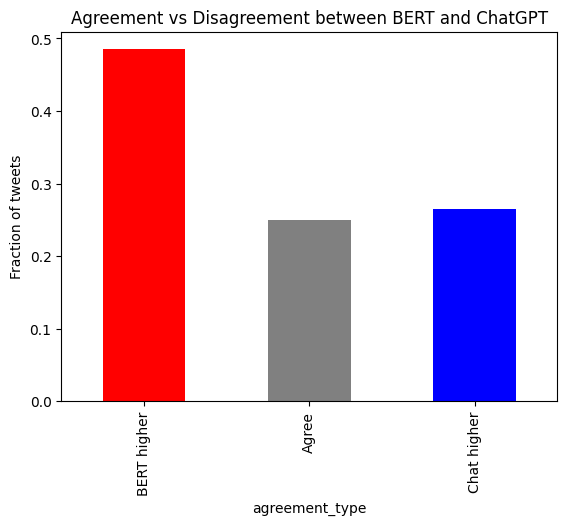

Agreement fractions (%):
agreement_type
BERT higher    48.5
Agree          25.0
Chat higher    26.5
Name: proportion, dtype: float64


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from google.colab import files
import io

# Upload your scored CSV (text, BERT, chat)
uploaded = files.upload()
csv_name = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[csv_name]))

# Clean
df["BERT"] = pd.to_numeric(df["BERT"], errors="coerce")
df["chat"] = pd.to_numeric(df["chat"], errors="coerce")
df = df.dropna(subset=["BERT","chat"])
df["gap"] = df["chat"] - df["BERT"]

# Agreement bins
df["agreement_type"] = pd.cut(df["gap"],
    bins=[-1, -0.15, 0.15, 1],
    labels=["BERT higher","Agree","Chat higher"]
)

counts = df["agreement_type"].value_counts(normalize=True).sort_index()
counts.plot(kind="bar", color=["red","gray","blue"])
plt.title("Agreement vs Disagreement between BERT and ChatGPT")
plt.ylabel("Fraction of tweets")
plt.show()

print("Agreement fractions (%):")
print((counts*100).round(2))


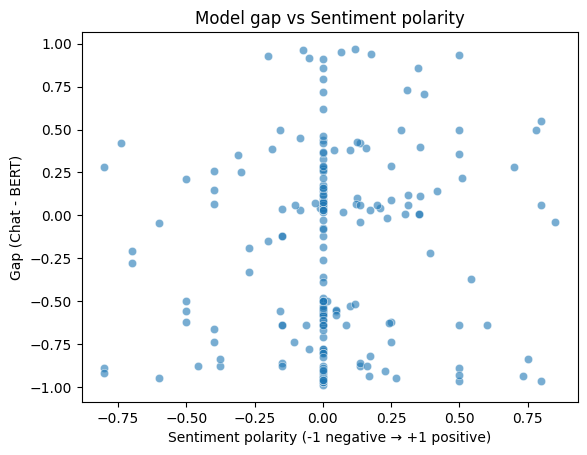

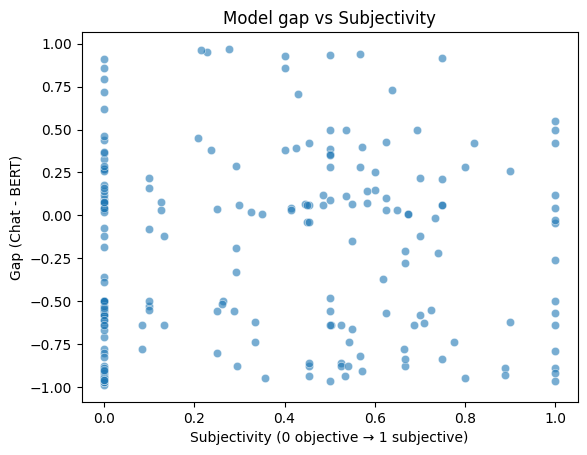

              sentiment  subjectivity    gap
sentiment         1.000         0.029  0.098
subjectivity      0.029         1.000  0.033
gap               0.098         0.033  1.000


In [ ]:
from textblob import TextBlob

df["sentiment"] = df["text"].apply(lambda s: TextBlob(str(s)).sentiment.polarity)
df["subjectivity"] = df["text"].apply(lambda s: TextBlob(str(s)).sentiment.subjectivity)

import seaborn as sns
sns.scatterplot(data=df, x="sentiment", y="gap", alpha=0.6)
plt.title("Model gap vs Sentiment polarity")
plt.xlabel("Sentiment polarity (-1 negative → +1 positive)")
plt.ylabel("Gap (Chat - BERT)")
plt.show()

sns.scatterplot(data=df, x="subjectivity", y="gap", alpha=0.6)
plt.title("Model gap vs Subjectivity")
plt.xlabel("Subjectivity (0 objective → 1 subjective)")
plt.ylabel("Gap (Chat - BERT)")
plt.show()

print(df[["sentiment","subjectivity","gap"]].corr().round(3))


Usable rows for models: 200

=== KMeans cluster summary (means) ===
          BERT   chat    gap
cluster                     
0        0.533  0.337 -0.196
1        0.271  0.108 -0.164
2        0.000  0.100  0.100


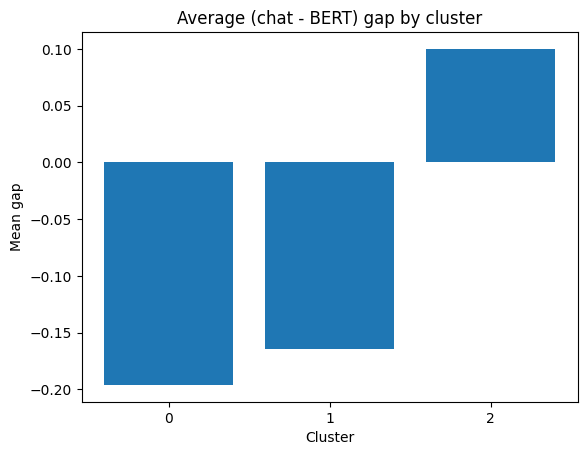

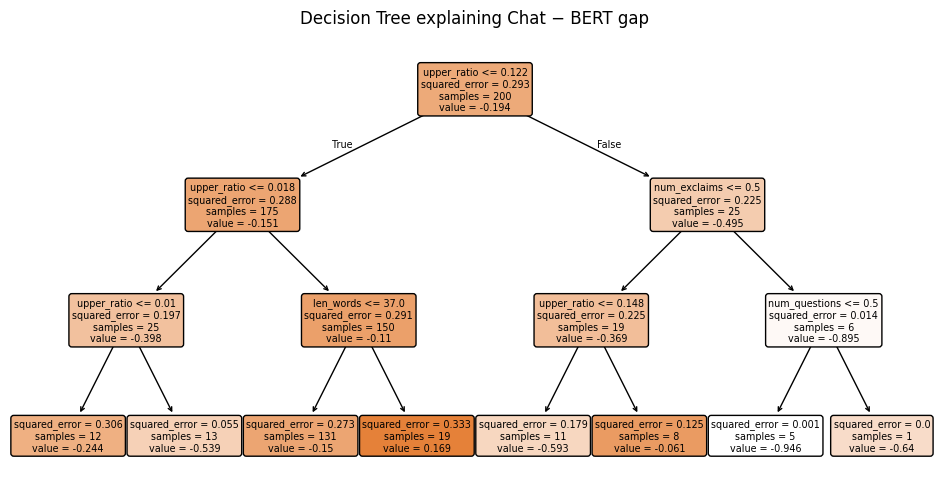

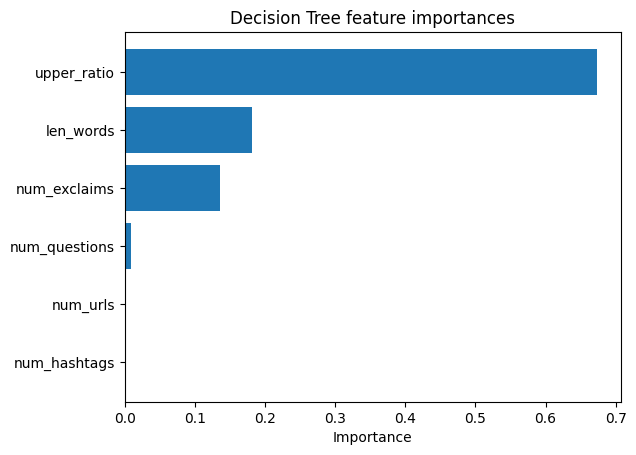

In [ ]:
# --- Robust prep + KMeans (3) + Decision Tree (5) ---
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeRegressor, plot_tree

# 0) Ensure required columns exist (recompute if needed)
def count_pattern(s, pattern):
    return len(re.findall(pattern, s))

def uppercase_ratio(s):
    s = str(s)
    ups = sum(1 for ch in s if ch.isupper())
    letters = sum(1 for ch in s if ch.isalpha())
    return ups / letters if letters > 0 else 0.0

def url_count(s):
    return len(re.findall(r"(https?://\S+)", str(s)))

def word_count(s):
    return len(re.findall(r"\b\w+\b", str(s)))

text_col = "text" if "text" in df.columns else ("tweets" if "tweets" in df.columns else None)
if text_col is None:
    for c in df.columns:
        if df[c].dtype == object:
            text_col = c
            break
if text_col is None:
    raise ValueError("Couldn't find a text column.")

# Recompute features if missing
if "len_words" not in df.columns:      df["len_words"] = df[text_col].astype(str).apply(word_count)
if "upper_ratio" not in df.columns:    df["upper_ratio"] = df[text_col].astype(str).apply(uppercase_ratio)
if "num_hashtags" not in df.columns:   df["num_hashtags"] = df[text_col].astype(str).apply(lambda s: count_pattern(s, r"#\w+"))
if "num_exclaims" not in df.columns:   df["num_exclaims"] = df[text_col].astype(str).apply(lambda s: s.count("!"))
if "num_questions" not in df.columns:  df["num_questions"] = df[text_col].astype(str).apply(lambda s: s.count("?"))
if "num_urls" not in df.columns:       df["num_urls"] = df[text_col].astype(str).apply(url_count)
if "gap" not in df.columns:            df["gap"] = pd.to_numeric(df["chat"], errors="coerce") - pd.to_numeric(df["BERT"], errors="coerce")

# 1) Build X and clean it
feat_cols = ["len_words","upper_ratio","num_hashtags","num_exclaims","num_questions","num_urls"]
X = df[feat_cols].copy()

# Coerce to numeric, handle junk
for c in feat_cols:
    X[c] = pd.to_numeric(X[c], errors="coerce")
y = pd.to_numeric(df["gap"], errors="coerce")

# Replace inf with NaN, then drop rows with any NaNs across X or y
X = X.replace([np.inf, -np.inf], np.nan)
bad_mask = X.isna().any(axis=1) | y.isna()
n_bad = bad_mask.sum()
if n_bad > 0:
    print(f"Dropping {n_bad} rows with NaNs/infs in features or target.")
Xc = X[~bad_mask].copy()
yc = y[~bad_mask].copy()

print(f"Usable rows for models: {len(Xc)}")

# 2) ---- Method 3: KMeans clustering on standardized features ----
if len(Xc) >= 3:  # need at least a few rows to cluster
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(Xc)

    # Choose k safely: at most number of unique points
    k = 3 if len(Xc) >= 6 else max(2, min(3, len(Xc)))
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    clusters = kmeans.fit_predict(X_scaled)

    # Attach cluster labels back to the filtered frame, then to original index for joins if needed
    df_clustered = df.loc[~bad_mask, :].copy()
    df_clustered["cluster"] = clusters

    # Summaries
    cluster_summary = df_clustered.groupby("cluster")[["BERT","chat","gap"]].mean().round(3)
    print("\n=== KMeans cluster summary (means) ===")
    print(cluster_summary)

    # Plot mean gap by cluster
    plt.figure()
    plt.bar(cluster_summary.index.astype(str), cluster_summary["gap"])
    plt.title("Average (chat - BERT) gap by cluster")
    plt.xlabel("Cluster")
    plt.ylabel("Mean gap")
    plt.show()
else:
    print("Not enough clean rows for KMeans clustering.")

# 3) ---- Method 5: Decision Tree for gap ----
if len(Xc) >= 5:
    tree = DecisionTreeRegressor(max_depth=3, random_state=42)
    tree.fit(Xc, yc)

    plt.figure(figsize=(12, 6))
    plot_tree(tree, feature_names=feat_cols, filled=True, rounded=True)
    plt.title("Decision Tree explaining Chat − BERT gap")
    plt.show()

    # Feature importances
    importances = pd.Series(tree.feature_importances_, index=feat_cols).sort_values(ascending=True)
    plt.figure()
    plt.barh(importances.index, importances.values)
    plt.title("Decision Tree feature importances")
    plt.xlabel("Importance")
    plt.show()
else:
    print("Not enough clean rows for Decision Tree.")



In [ ]:
from collections import Counter
import re

def tokenize(s):
    return re.findall(r"\b[a-zA-Z#@']+\b", str(s).lower())

df["disagree"] = df["gap"].abs() > 0.15
top_words = Counter()
top_words_disagree = Counter()

for text, dis in zip(df["text"], df["disagree"]):
    tokens = tokenize(text)
    if dis:
        top_words_disagree.update(tokens)
    else:
        top_words.update(tokens)

# Compute relative frequencies
total_dis = sum(top_words_disagree.values())
total_all = sum(top_words.values())
ratios = []
for w in top_words_disagree:
    f_dis = top_words_disagree[w] / total_dis
    f_all = top_words[w] / total_all if w in top_words else 1e-6
    ratios.append((w, f_dis / f_all))
ratios = sorted(ratios, key=lambda x: x[1], reverse=True)
print("Top words overrepresented in disagreement cases:")
print(ratios[:20])


Top words overrepresented in disagreement cases:
[('can', 4989.308624376337), ('them', 4276.550249465432), ('more', 2851.033499643621), ('man', 2494.6543121881687), ('here', 2138.275124732716), ('need', 2138.275124732716), ('should', 2138.275124732716), ('said', 1781.895937277263), ('member', 1781.895937277263), ('me', 1781.895937277263), ('see', 1781.895937277263), ('many', 1781.895937277263), ('illegal', 1781.895937277263), ('got', 1781.895937277263), ('scotus', 1781.895937277263), ("didn't", 1781.895937277263), ('woman', 1781.895937277263), ('also', 1781.895937277263), ('god', 1781.895937277263), ('gun', 1781.895937277263)]
